# 02 - OpenCV, NumPy, Matplotlib

In this notebook, we practice the practical Python tools used for image handling in VisionInspect AI.

- OpenCV reads, converts, resizes, and saves images.
- NumPy lets us treat images as arrays/matrices.
- Matplotlib displays images clearly inside notebooks.

## Learning Goals

By the end of this notebook, you should be able to:

1. Read an image using OpenCV.
2. Understand why OpenCV uses BGR instead of RGB.
3. Display images using Matplotlib.
4. Inspect image shape, dtype, and pixel values.
5. Access and modify pixels using NumPy indexing.
6. Crop, resize, flip, and save images.
7. Plot multiple image outputs side by side.

In [1]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SAMPLE_DIR = PROJECT_ROOT / "data" / "sample_images"
OUTPUT_DIR = PROJECT_ROOT / "data" / "processed" / "opencv_practice"

SAMPLE_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Sample directory:", SAMPLE_DIR)
print("Output directory:", OUTPUT_DIR)

Project root: C:\Users\HP\Desktop\springboard\visioninspect-ai
Sample directory: C:\Users\HP\Desktop\springboard\visioninspect-ai\data\sample_images
Output directory: C:\Users\HP\Desktop\springboard\visioninspect-ai\data\processed\opencv_practice


## Create Or Load A Sample Image

Notebook 1 saved a synthetic image. If that file is missing, this cell creates a new sample image automatically.

In [2]:
sample_path = SAMPLE_DIR / "synthetic_rgb.png"

if not sample_path.exists():
    image_rgb = np.zeros((160, 220, 3), dtype=np.uint8)

    # Background gradient
    for row in range(image_rgb.shape[0]):
        image_rgb[row, :, 0] = np.linspace(30, 210, image_rgb.shape[1])
        image_rgb[row, :, 1] = row
        image_rgb[row, :, 2] = 120

    # Add colored inspection-like regions
    image_rgb[25:80, 30:90] = [230, 40, 40]
    image_rgb[55:125, 120:185] = [40, 210, 90]
    image_rgb[95:145, 45:105] = [40, 90, 230]

    # OpenCV saves in BGR, so convert RGB to BGR before saving.
    image_bgr = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2BGR)
    cv2.imwrite(str(sample_path), image_bgr)

print("Sample image path:", sample_path)
print("Exists:", sample_path.exists())

Sample image path: C:\Users\HP\Desktop\springboard\visioninspect-ai\data\sample_images\synthetic_rgb.png
Exists: True


## Read Image With OpenCV

`cv2.imread()` loads images in **BGR** order.

Matplotlib expects **RGB** order.

So for correct display in notebooks, we convert:

`BGR -> RGB`

In [3]:
image_bgr = cv2.imread(str(sample_path))

if image_bgr is None:
    raise FileNotFoundError(f"Could not read image: {sample_path}")

image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

print("BGR image shape:", image_bgr.shape)
print("RGB image shape:", image_rgb.shape)
print("Data type:", image_rgb.dtype)
print("Min intensity:", image_rgb.min())
print("Max intensity:", image_rgb.max())

BGR image shape: (160, 220, 3)
RGB image shape: (160, 220, 3)
Data type: uint8
Min intensity: 0
Max intensity: 230


## Display BGR vs RGB

If you display an OpenCV BGR image directly in Matplotlib, colors can look wrong. The RGB-converted version is the correct display.

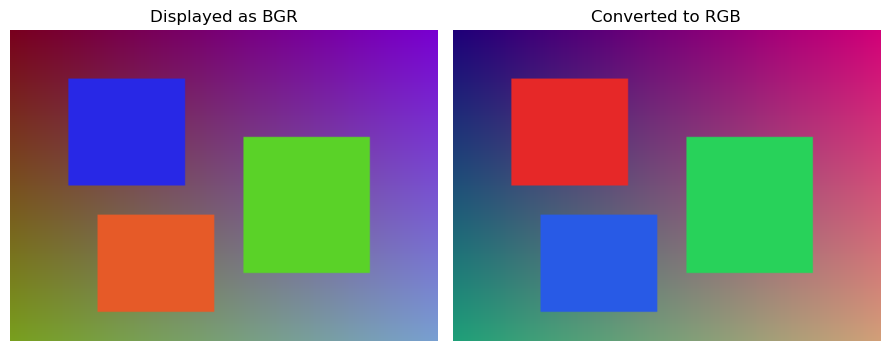

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))

axes[0].imshow(image_bgr)
axes[0].set_title("Displayed as BGR")

axes[1].imshow(image_rgb)
axes[1].set_title("Converted to RGB")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

## Image As NumPy Array

An image is a NumPy array.

Shape is:

`height, width, channels`

Pixel access format is:

`image[row, column]`

In [5]:
height, width, channels = image_rgb.shape

print("Height:", height)
print("Width:", width)
print("Channels:", channels)
print("Total pixels:", height * width)

row = height // 2
col = width // 2

print(f"Pixel at row={row}, col={col}:", image_rgb[row, col])

Height: 160
Width: 220
Channels: 3
Total pixels: 35200
Pixel at row=80, col=110: [120  80 120]


## Split Color Channels

A color image has separate red, green, and blue channels. We can split and inspect them individually.

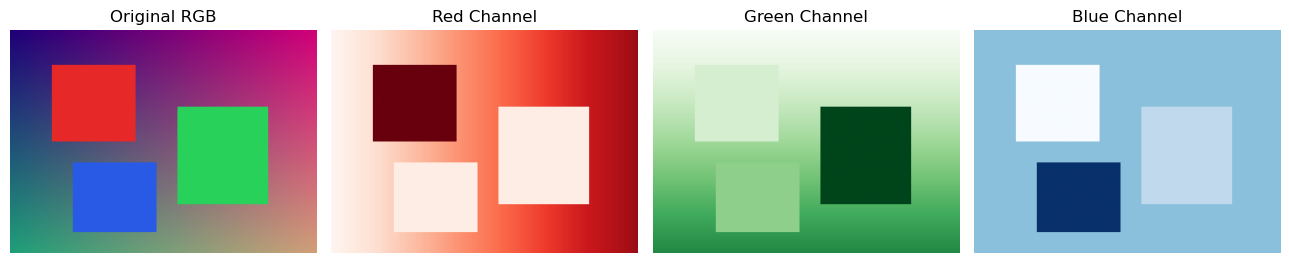

In [6]:
red_channel = image_rgb[:, :, 0]
green_channel = image_rgb[:, :, 1]
blue_channel = image_rgb[:, :, 2]

fig, axes = plt.subplots(1, 4, figsize=(13, 4))

axes[0].imshow(image_rgb)
axes[0].set_title("Original RGB")

axes[1].imshow(red_channel, cmap="Reds")
axes[1].set_title("Red Channel")

axes[2].imshow(green_channel, cmap="Greens")
axes[2].set_title("Green Channel")

axes[3].imshow(blue_channel, cmap="Blues")
axes[3].set_title("Blue Channel")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

## Convert To Grayscale

Grayscale images are useful for preprocessing, thresholding, blur detection, edges, and many classical image-processing operations.

Grayscale shape: (160, 220)
Grayscale dtype: uint8
Grayscale min/max: 23 170


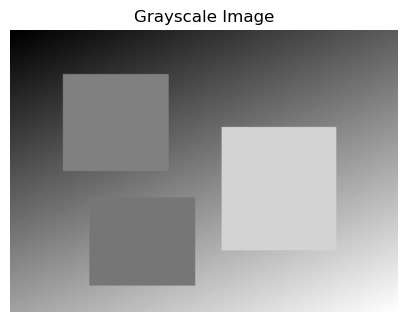

In [7]:
gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)

print("Grayscale shape:", gray.shape)
print("Grayscale dtype:", gray.dtype)
print("Grayscale min/max:", gray.min(), gray.max())

plt.figure(figsize=(5, 4))
plt.imshow(gray, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

## Pixel Manipulation

Because images are arrays, we can modify pixels directly.

Below we draw a red square and a white horizontal line using NumPy slicing.

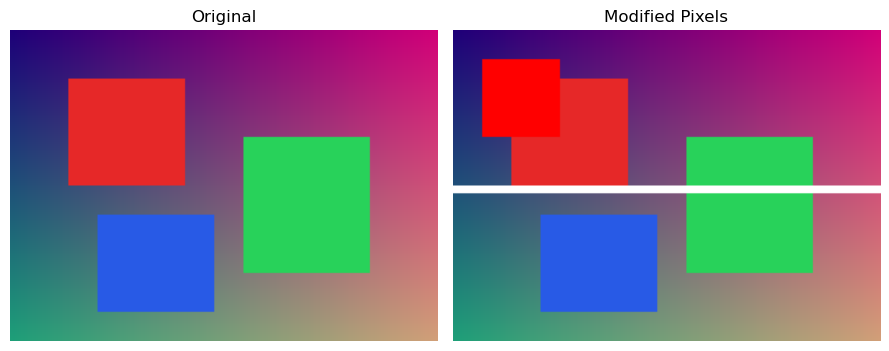

In [8]:
modified_rgb = image_rgb.copy()

# Red square: rows 15-55, columns 15-55
modified_rgb[15:55, 15:55] = [255, 0, 0]

# White line across the image
line_row = modified_rgb.shape[0] // 2
modified_rgb[line_row:line_row + 4, :] = [255, 255, 255]

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].imshow(image_rgb)
axes[0].set_title("Original")
axes[1].imshow(modified_rgb)
axes[1].set_title("Modified Pixels")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

## Crop An Image

Cropping also uses NumPy slicing:

`cropped = image[start_row:end_row, start_col:end_col]`

Original shape: (160, 220, 3)
Crop shape: (100, 120, 3)


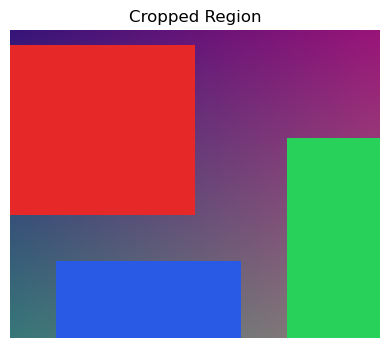

In [9]:
crop = image_rgb[20:120, 30:150]

print("Original shape:", image_rgb.shape)
print("Crop shape:", crop.shape)

plt.figure(figsize=(5, 4))
plt.imshow(crop)
plt.title("Cropped Region")
plt.axis("off")
plt.show()

## Resize Image

For machine learning, images usually need a fixed size such as 224 x 224 or 256 x 256.

Before resize: (160, 220, 3)
After resize: (256, 256, 3)


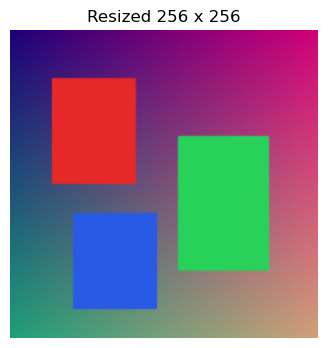

In [10]:
resized_rgb = cv2.resize(image_rgb, (256, 256))

print("Before resize:", image_rgb.shape)
print("After resize:", resized_rgb.shape)

plt.figure(figsize=(4, 4))
plt.imshow(resized_rgb)
plt.title("Resized 256 x 256")
plt.axis("off")
plt.show()

## Flip And Rotate

These operations are useful for data augmentation and understanding orientation changes.

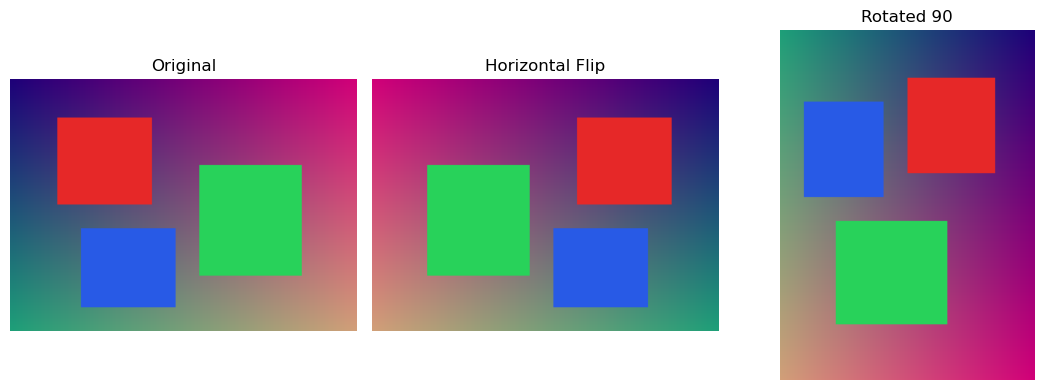

In [11]:
flipped_rgb = cv2.flip(image_rgb, 1)
rotated_rgb = cv2.rotate(image_rgb, cv2.ROTATE_90_CLOCKWISE)

fig, axes = plt.subplots(1, 3, figsize=(11, 4))

axes[0].imshow(image_rgb)
axes[0].set_title("Original")

axes[1].imshow(flipped_rgb)
axes[1].set_title("Horizontal Flip")

axes[2].imshow(rotated_rgb)
axes[2].set_title("Rotated 90")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

## Save Images With OpenCV

OpenCV saves color images in BGR order, so convert RGB back to BGR before saving.

In [12]:
modified_bgr = cv2.cvtColor(modified_rgb, cv2.COLOR_RGB2BGR)
resized_bgr = cv2.cvtColor(resized_rgb, cv2.COLOR_RGB2BGR)

modified_path = OUTPUT_DIR / "modified_pixels.png"
gray_path = OUTPUT_DIR / "grayscale.png"
resized_path = OUTPUT_DIR / "resized_256.png"

cv2.imwrite(str(modified_path), modified_bgr)
cv2.imwrite(str(gray_path), gray)
cv2.imwrite(str(resized_path), resized_bgr)

print("Saved:")
print(modified_path)
print(gray_path)
print(resized_path)

Saved:
C:\Users\HP\Desktop\springboard\visioninspect-ai\data\processed\opencv_practice\modified_pixels.png
C:\Users\HP\Desktop\springboard\visioninspect-ai\data\processed\opencv_practice\grayscale.png
C:\Users\HP\Desktop\springboard\visioninspect-ai\data\processed\opencv_practice\resized_256.png


## Mini Program: Read -> Grayscale -> Resize -> Save

This is the small program mentioned in the project workflow.

Mini program output shape: (256, 256)
Saved to: C:\Users\HP\Desktop\springboard\visioninspect-ai\data\processed\opencv_practice\mini_program_output.png


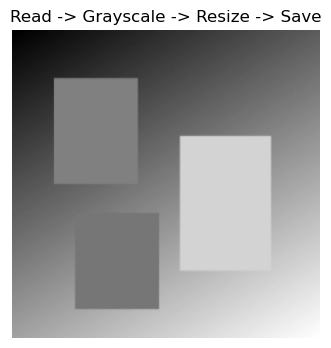

In [13]:
def convert_grayscale_resize_save(input_path, output_path, size=(256, 256)):
    image = cv2.imread(str(input_path))
    if image is None:
        raise FileNotFoundError(f"Could not read image: {input_path}")

    gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    resized_image = cv2.resize(gray_image, size)
    cv2.imwrite(str(output_path), resized_image)

    return resized_image


mini_output_path = OUTPUT_DIR / "mini_program_output.png"
mini_output = convert_grayscale_resize_save(sample_path, mini_output_path)

print("Mini program output shape:", mini_output.shape)
print("Saved to:", mini_output_path)

plt.figure(figsize=(4, 4))
plt.imshow(mini_output, cmap="gray")
plt.title("Read -> Grayscale -> Resize -> Save")
plt.axis("off")
plt.show()

## Summary

You practiced the core image-handling tools:

- `cv2.imread()` for reading images
- `cv2.cvtColor()` for BGR/RGB/grayscale conversion
- NumPy indexing for pixel access and manipulation
- Matplotlib for displaying images in notebooks
- `cv2.resize()` for fixed model input size
- `cv2.imwrite()` for saving outputs

Next notebook: `03_image_preprocessing.ipynb`.